# Netflix Content Analysis (EDA)

This project explores Netflix's catalog of movies and television shows
to understand trends in content production, geographic distribution,
and genre popularity.

The analysis focuses on answering the following questions:

- How has Netflix's content library grown over time?
- What proportion of content is movies vs TV shows?
- Which countries produce the most Netflix content?
- What genres dominate Netflix's catalog?

Dataset Source:
https://www.kaggle.com/datasets/shivamb/netflix-shows

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10,6)
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 12

In [19]:
# Load dataset
df = pd.read_csv("../data/netflix_titles.csv")

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [20]:
# Basic dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [21]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [22]:
df.shape

(8807, 12)

In [23]:
# Missing Values
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [24]:
# Data cleaning
df['director'] = df['director'].fillna("Unknown")
df['cast'] = df['cast'].fillna("Unknown")
df['country'] = df['country'].fillna("Unknown")
df['rating'] = df['rating'].fillna("Unknown")
df['duration'] = df['duration'].fillna("Unknown")

In [27]:
# Convert date column
df['date_added'] = pd.to_datetime(
    df['date_added'].astype(str).str.strip(),
    errors='coerce'
)

In [28]:
# Create a Y-added column
df['year_added'] = df['date_added'].dt.year

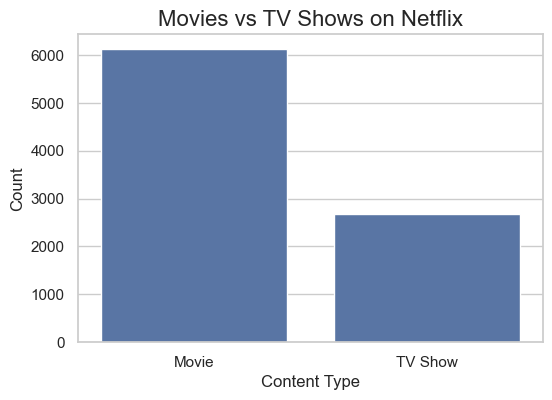

In [29]:
# Movies vs TV shows
plt.figure(figsize=(6,4))

sns.countplot(x='type', data=df)

plt.title("Movies vs TV Shows on Netflix")
plt.xlabel("Content Type")
plt.ylabel("Count")

plt.savefig("../images/charts/movies_vs_tvshows.png", bbox_inches="tight")

plt.show()

### Observation

Movies make up the majority of Netflix's catalog, indicating that
Netflix heavily emphasizes film content over television series.

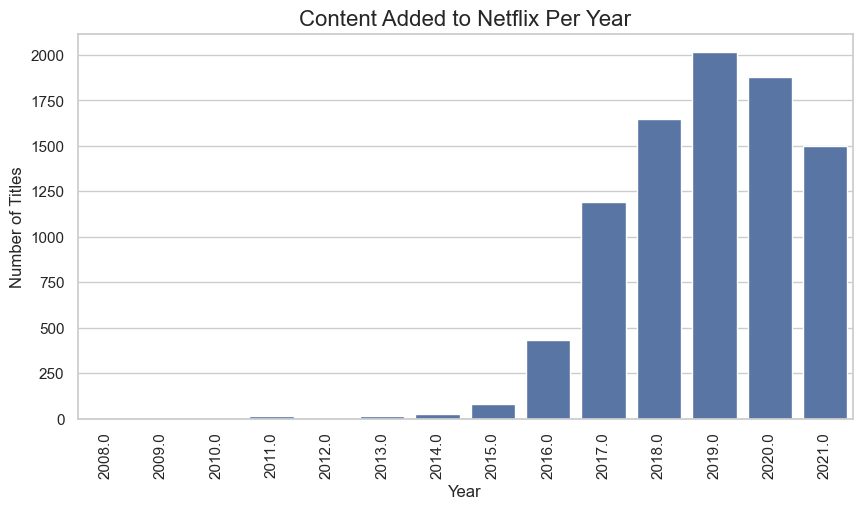

In [30]:
# Content added over time
plt.figure(figsize=(10,5))

sns.countplot(x='year_added', data=df)

plt.xticks(rotation=90)

plt.title("Content Added to Netflix Per Year")
plt.xlabel("Year")
plt.ylabel("Number of Titles")

plt.savefig("../images/charts/content_growth_by_type.png", bbox_inches="tight")

plt.show()

### Observation

Netflix's catalog grew rapidly between 2016 and 2020,
indicating an aggressive expansion of content during that period.

In [31]:
# Top producing countries
df['country'] = df['country'].str.split(',')
df_country = df.explode('country')

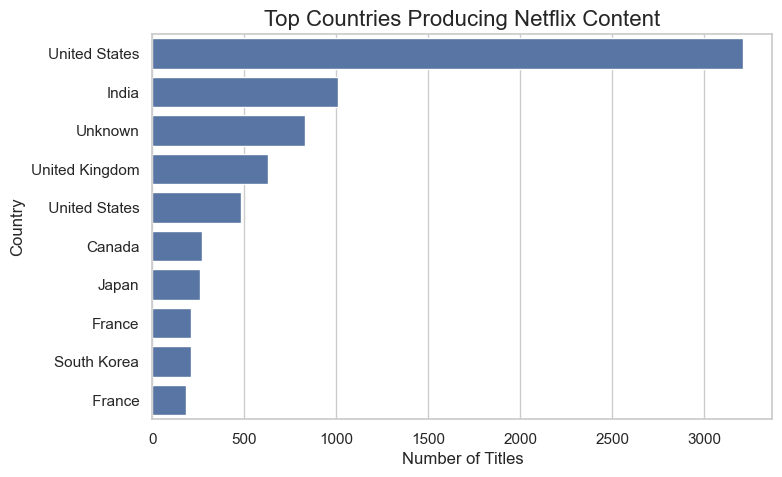

In [32]:
# Plot
top_countries = df_country['country'].value_counts().head(10)

plt.figure(figsize=(8,5))

sns.barplot(x=top_countries.values, y=top_countries.index)

plt.title("Top Countries Producing Netflix Content")
plt.xlabel("Number of Titles")
plt.ylabel("Country")

plt.savefig("../images/charts/top_countries.png", bbox_inches="tight")

plt.show()

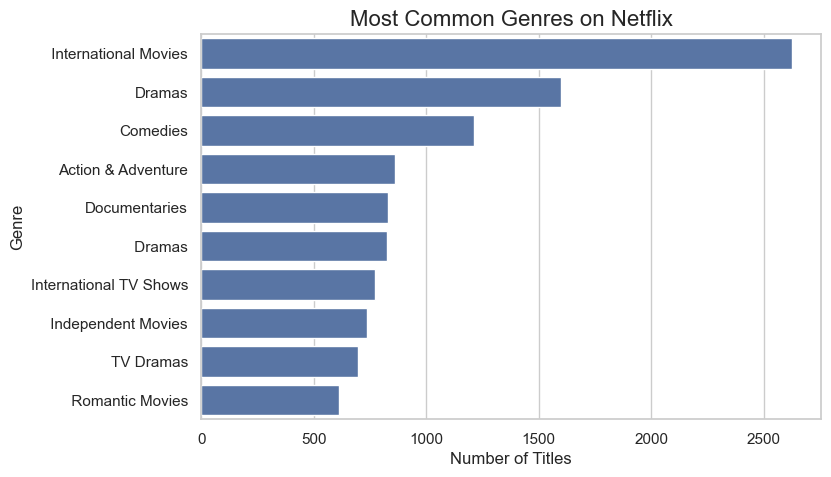

In [33]:
# Genre Analysis
df['listed_in'] = df['listed_in'].str.split(',')
df_genres = df.explode('listed_in')

top_genres = df_genres['listed_in'].value_counts().head(10)

plt.figure(figsize=(8,5))

sns.barplot(x=top_genres.values, y=top_genres.index)

plt.title("Most Common Genres on Netflix")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")

plt.savefig("../images/charts/top_genres.png", bbox_inches="tight")

plt.show()

In [34]:
# Movie Duration
movies = df[df['type'] == "Movie"].copy()

In [35]:
# Clean Duration
movies['duration'] = movies['duration'].str.replace(" min","")
movies['duration'] = pd.to_numeric(movies['duration'], errors='coerce')

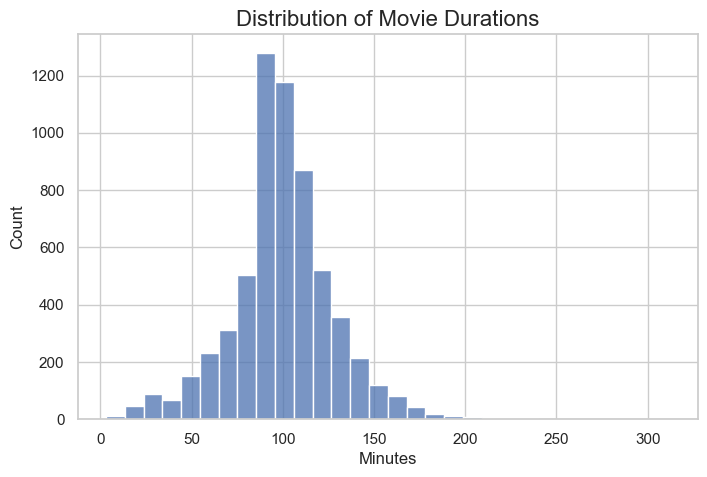

In [36]:
# plot
plt.figure(figsize=(8,5))

sns.histplot(movies['duration'], bins=30)

plt.title("Distribution of Movie Durations")
plt.xlabel("Minutes")
plt.ylabel("Count")

plt.show()

In [37]:
# Create pivot table
content_pivot = df.pivot_table(
    index="year_added",
    columns="type",
    values="title",
    aggfunc="count"
)

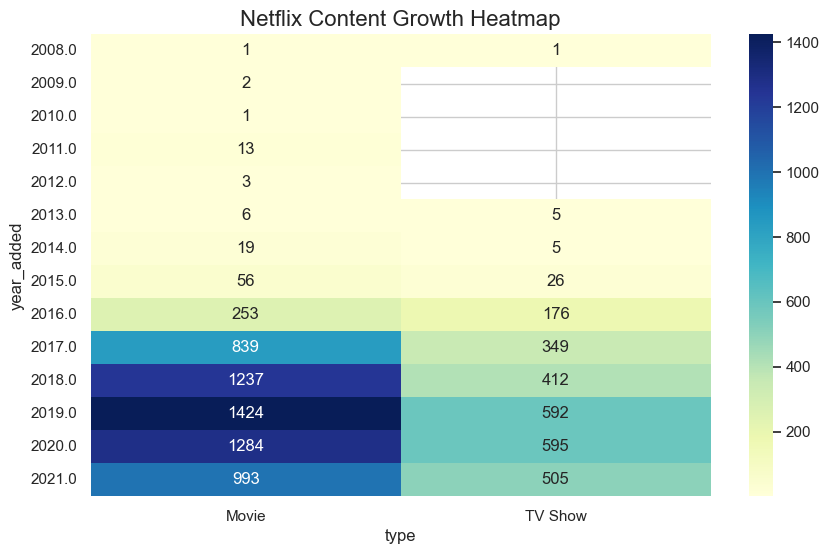

In [38]:
# Heatmap
plt.figure(figsize=(10,6))

sns.heatmap(
    content_pivot,
    cmap="YlGnBu",
    annot=True,
    fmt="g"
)

plt.title("Netflix Content Growth Heatmap")

plt.savefig("../images/charts/content_growth_heatmap.png", bbox_inches="tight")

plt.show()

# Key Insights

### Netflix Growth
Netflix's content catalog expanded rapidly between 2015 and 2020,
reflecting the company's global expansion and increased investment
in original programming.

### Content Type
Movies dominate the Netflix catalog, though the number of TV series
has grown significantly in recent years.

### Geographic Distribution
The United States produces the largest number of Netflix titles,
followed by India and the United Kingdom.

### Genre Trends
Drama and international films represent the most common genres
in the platform's catalog.